In [256]:
!pip install imbalanced-learn

In [257]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, TruncatedSVD
import matplotlib.patches as mpatches
import time

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import collections

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from imblearn.pipeline import make_pipeline as imbal_make_pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss
from imblearn.metrics import classification_report_imbalanced
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import f1_score, classification_report, confusion_matrix

from collections import Counter
from sklearn.model_selection import KFold, StratifiedKFold


In [258]:
import warnings
warnings.filterwarnings('ignore')

In [259]:
df_cc = pd.read_csv('creditcard.csv')

In [260]:
df_cc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11665 entries, 0 to 11664
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    11665 non-null  int64  
 1   V1      11665 non-null  float64
 2   V2      11665 non-null  float64
 3   V3      11665 non-null  float64
 4   V4      11665 non-null  float64
 5   V5      11665 non-null  float64
 6   V6      11665 non-null  float64
 7   V7      11665 non-null  float64
 8   V8      11665 non-null  float64
 9   V9      11665 non-null  float64
 10  V10     11665 non-null  float64
 11  V11     11665 non-null  float64
 12  V12     11664 non-null  float64
 13  V13     11664 non-null  float64
 14  V14     11664 non-null  float64
 15  V15     11664 non-null  float64
 16  V16     11664 non-null  float64
 17  V17     11664 non-null  float64
 18  V18     11664 non-null  float64
 19  V19     11664 non-null  float64
 20  V20     11664 non-null  float64
 21  V21     11664 non-null  float64
 22

In [261]:
df_cc.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [262]:
df_cc.iloc[:,1:].describe().T

,count,mean,std,min,25%,50%,75%,max
V1,11665.0,-0.219601,1.561122,-27.670569,-0.987193,-0.347783,1.159319,1.960497
V2,11665.0,0.274988,1.305785,-34.607649,-0.257287,0.262619,0.888750,9.067613
V3,11665.0,0.897990,1.272504,-21.405836,0.416175,0.950034,1.616224,4.101716
V4,11665.0,0.281016,1.467970,-4.657545,-0.615559,0.215393,1.153380,11.927512
V5,11665.0,-0.078995,1.184333,-32.092129,-0.680719,-0.179654,0.348187,34.099309
V6,11665.0,0.140055,1.305472,-23.496714,-0.622413,-0.147786,0.508886,21.393069
V7,11665.0,-0.111620,1.129256,-26.548144,-0.583742,-0.088491,0.439387,34.303177
V8,11665.0,-0.051877,1.236992,-23.632502,-0.186419,0.011665,0.267067,5.499963
V9,11665.0,0.893589,1.182130,-7.175097,0.181510,0.880826,1.570361,10.392889
V10,11665.0,-0.271198,1.157531,-14.166795,-0.720219,-0.357116,0.153227,12.259949


In [263]:
#check null values
df_cc.isnull().sum().sum()

np.int64(19)

In [264]:
df_cc[df_cc.isnull().any(axis=1)]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
11664,19915,1.504229,-0.499337,0.052377,-0.576345,-0.393971,0.015149,-0.718603,-0.125852,1.023281,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [265]:
df_cc = df_cc.drop(index=df_cc[df_cc.isnull().any(axis=1)].index)

In [266]:
df_cc['Class'].value_counts(normalize=True) * 100

,proportion
Class,
0.0,99.579904
1.0,0.420096


In [267]:
df_cc

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11659,19914,1.348167,-0.531813,0.737667,-0.312410,-1.147767,-0.585711,-0.810412,-0.062116,0.705208,...,-0.120215,-0.076450,0.006995,0.489243,0.448523,-0.309831,-0.021411,-0.003987,5.00,0.0
11660,19915,1.294875,-0.645847,0.689549,-0.351634,-1.026884,-0.129811,-0.928101,0.114172,0.804717,...,-0.097462,-0.020893,0.040297,0.159282,0.350705,-0.278351,-0.010354,-0.008003,10.00,0.0
11661,19915,1.404683,-0.554883,0.612239,-0.234956,-1.190992,-0.816824,-0.775771,-0.142637,1.121638,...,-0.196110,-0.303562,0.005661,0.313352,0.473813,-0.276618,-0.024026,0.002106,5.00,0.0
11662,19915,-0.945541,0.479754,1.521916,-1.298658,-0.852548,-0.604029,-0.354686,0.498106,0.407159,...,-0.050745,0.056031,-0.055584,0.312195,0.026299,-0.413466,0.189152,0.086360,10.00,0.0


<Axes: xlabel='Class', ylabel='count'>

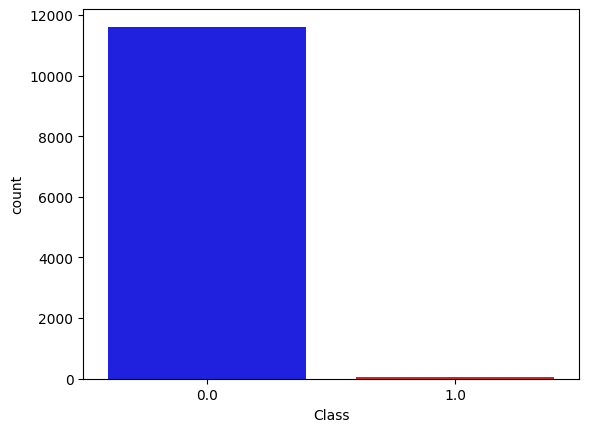

In [268]:
sns.countplot(x='Class', data=df_cc, palette=['blue', 'red'])

In [269]:
df_cc['Amount'].value_counts().max()

655

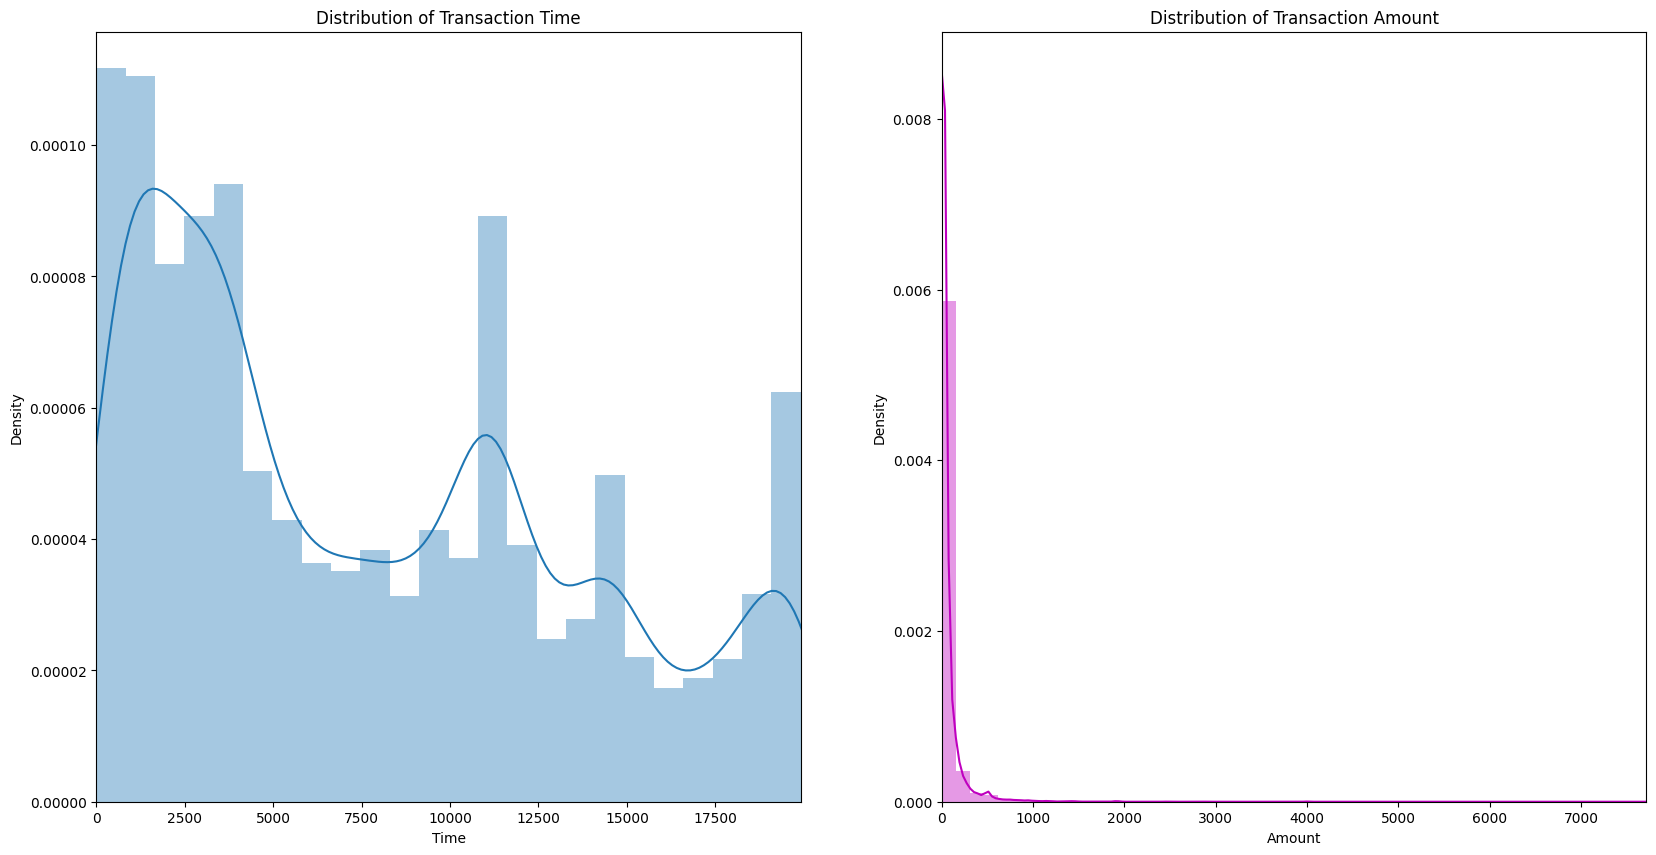

In [270]:
#distributions
fig, axes = plt.subplots(1, 2, figsize=(20,10))
# sns.histplot(x='Time', data=df_cc, ax=axes[0])
sns.distplot(df_cc['Time'], ax=axes[0])
axes[0].set_xlim(df_cc['Time'].min(), df_cc['Time'].max())
axes[0].set_title('Distribution of Transaction Time')

# sns.histplot(x='Amount', data=df_cc, ax=axes[1], color='m')
sns.distplot(df_cc['Amount'], ax=axes[1], color='m')
axes[1].set_xlim(df_cc['Amount'].min(), df_cc['Amount'].max())
axes[1].set_title('Distribution of Transaction Amount')

plt.show()

In [271]:
# Robust scaler is less prone to outliers
from sklearn.preprocessing import RobustScaler
rs = RobustScaler()

In [272]:
df_cc['Amount'].values

array([149.62,   2.69, 378.66, ...,   5.  ,  10.  ,  10.  ])

In [273]:
from sklearn.preprocessing import StandardScaler
StandardScaler().fit_transform(df_cc['Amount'].values.reshape(-1,1))

array([[ 0.48287256],
       [-0.33427196],
       [ 1.75666812],
       ...,
       [-0.321425  ],
       [-0.29361773],
       [-0.29361773]])

In [274]:
df_cc.insert(1, 'STime',
             rs.fit_transform(df_cc['Time'].values.reshape(-1,1)))
df_cc.insert(0, 'SAmount',
             rs.fit_transform(df_cc['Amount'].values.reshape(-1,1)))

In [275]:
df_cc = df_cc.drop(columns=['Amount', 'Time'])

In [276]:
df_cc

,SAmount,STime,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,2.970444,-0.668681,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.0
1,-0.294667,-0.668681,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0.0
2,8.060222,-0.668575,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0.0
3,2.390000,-0.668575,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.0
4,1.200889,-0.668469,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11659,-0.243333,1.442307,1.348167,-0.531813,0.737667,-0.312410,-1.147767,-0.585711,-0.810412,-0.062116,...,-0.060712,-0.120215,-0.076450,0.006995,0.489243,0.448523,-0.309831,-0.021411,-0.003987,0.0
11660,-0.132222,1.442413,1.294875,-0.645847,0.689549,-0.351634,-1.026884,-0.129811,-0.928101,0.114172,...,-0.126197,-0.097462,-0.020893,0.040297,0.159282,0.350705,-0.278351,-0.010354,-0.008003,0.0
11661,-0.243333,1.442413,1.404683,-0.554883,0.612239,-0.234956,-1.190992,-0.816824,-0.775771,-0.142637,...,-0.125651,-0.196110,-0.303562,0.005661,0.313352,0.473813,-0.276618,-0.024026,0.002106,0.0
11662,-0.132222,1.442413,-0.945541,0.479754,1.521916,-1.298658,-0.852548,-0.604029,-0.354686,0.498106,...,-0.106545,-0.050745,0.056031,-0.055584,0.312195,0.026299,-0.413466,0.189152,0.086360,0.0


In [277]:
df_cc_org = df_cc.copy(deep=True)

In [278]:
# fraud and non-fraud are not equally distributted,
# apply under-sampling and over-sampling to duplicate data
df_cc_os = pd.concat([df_cc[df_cc['Class']==1].
                   sample(frac=100, replace=True),df_cc])
# df_cc.sample(frac=1)
# df_cc.shape

In [279]:
df_cc_os = df_cc_os.sample(frac=1, replace=True).reset_index(drop=True)

<Axes: xlabel='Class', ylabel='count'>

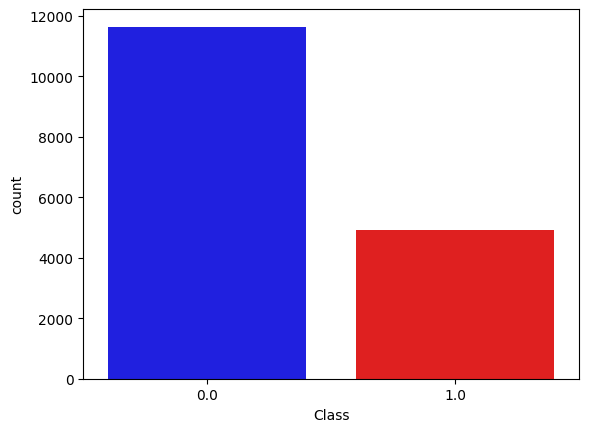

In [280]:
sns.countplot(x='Class', data=df_cc_os, palette=['b','r'])

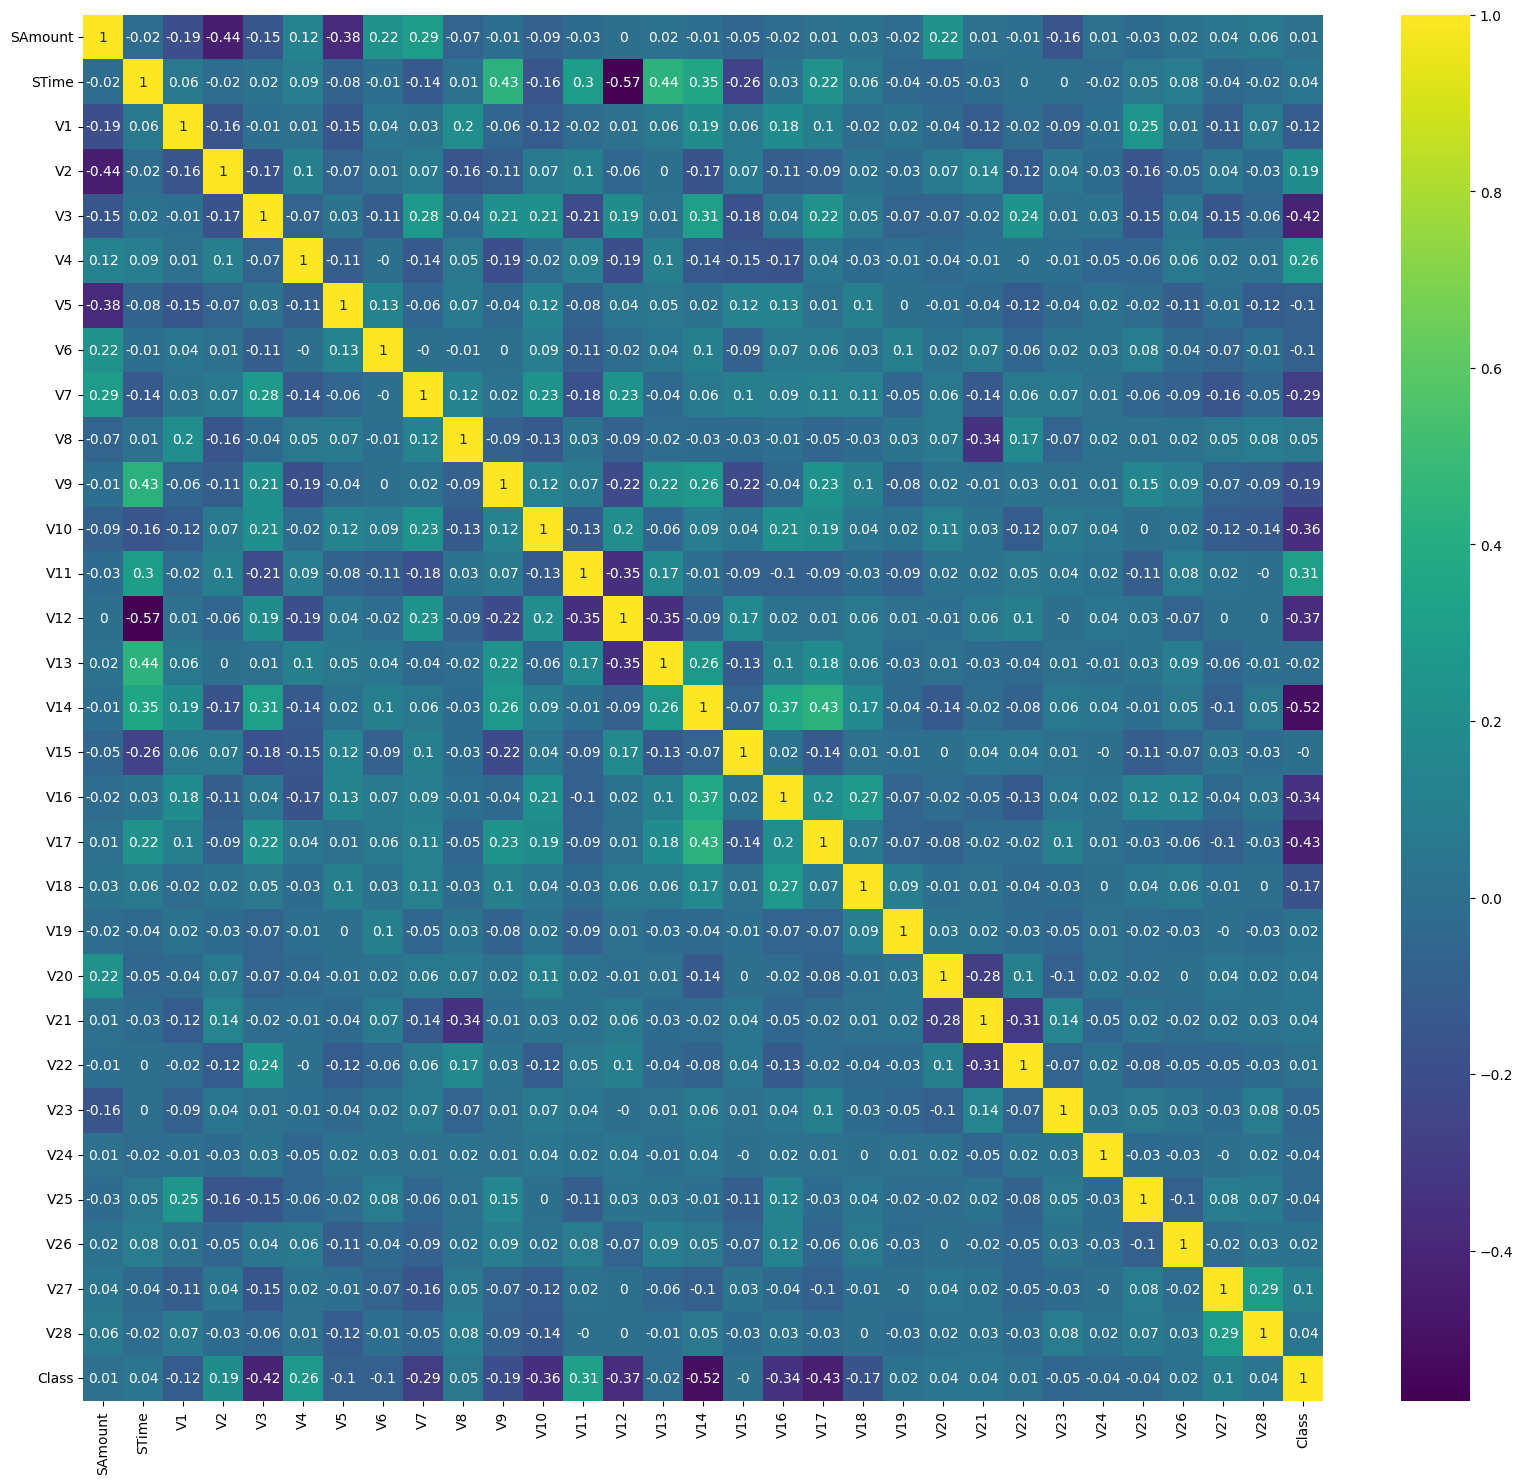

In [281]:
#check correlation of both over sampled and original data
plt.figure(figsize=(20,18))
sns.heatmap(df_cc.corr().round(2), annot=True, cmap='viridis')
plt.show()

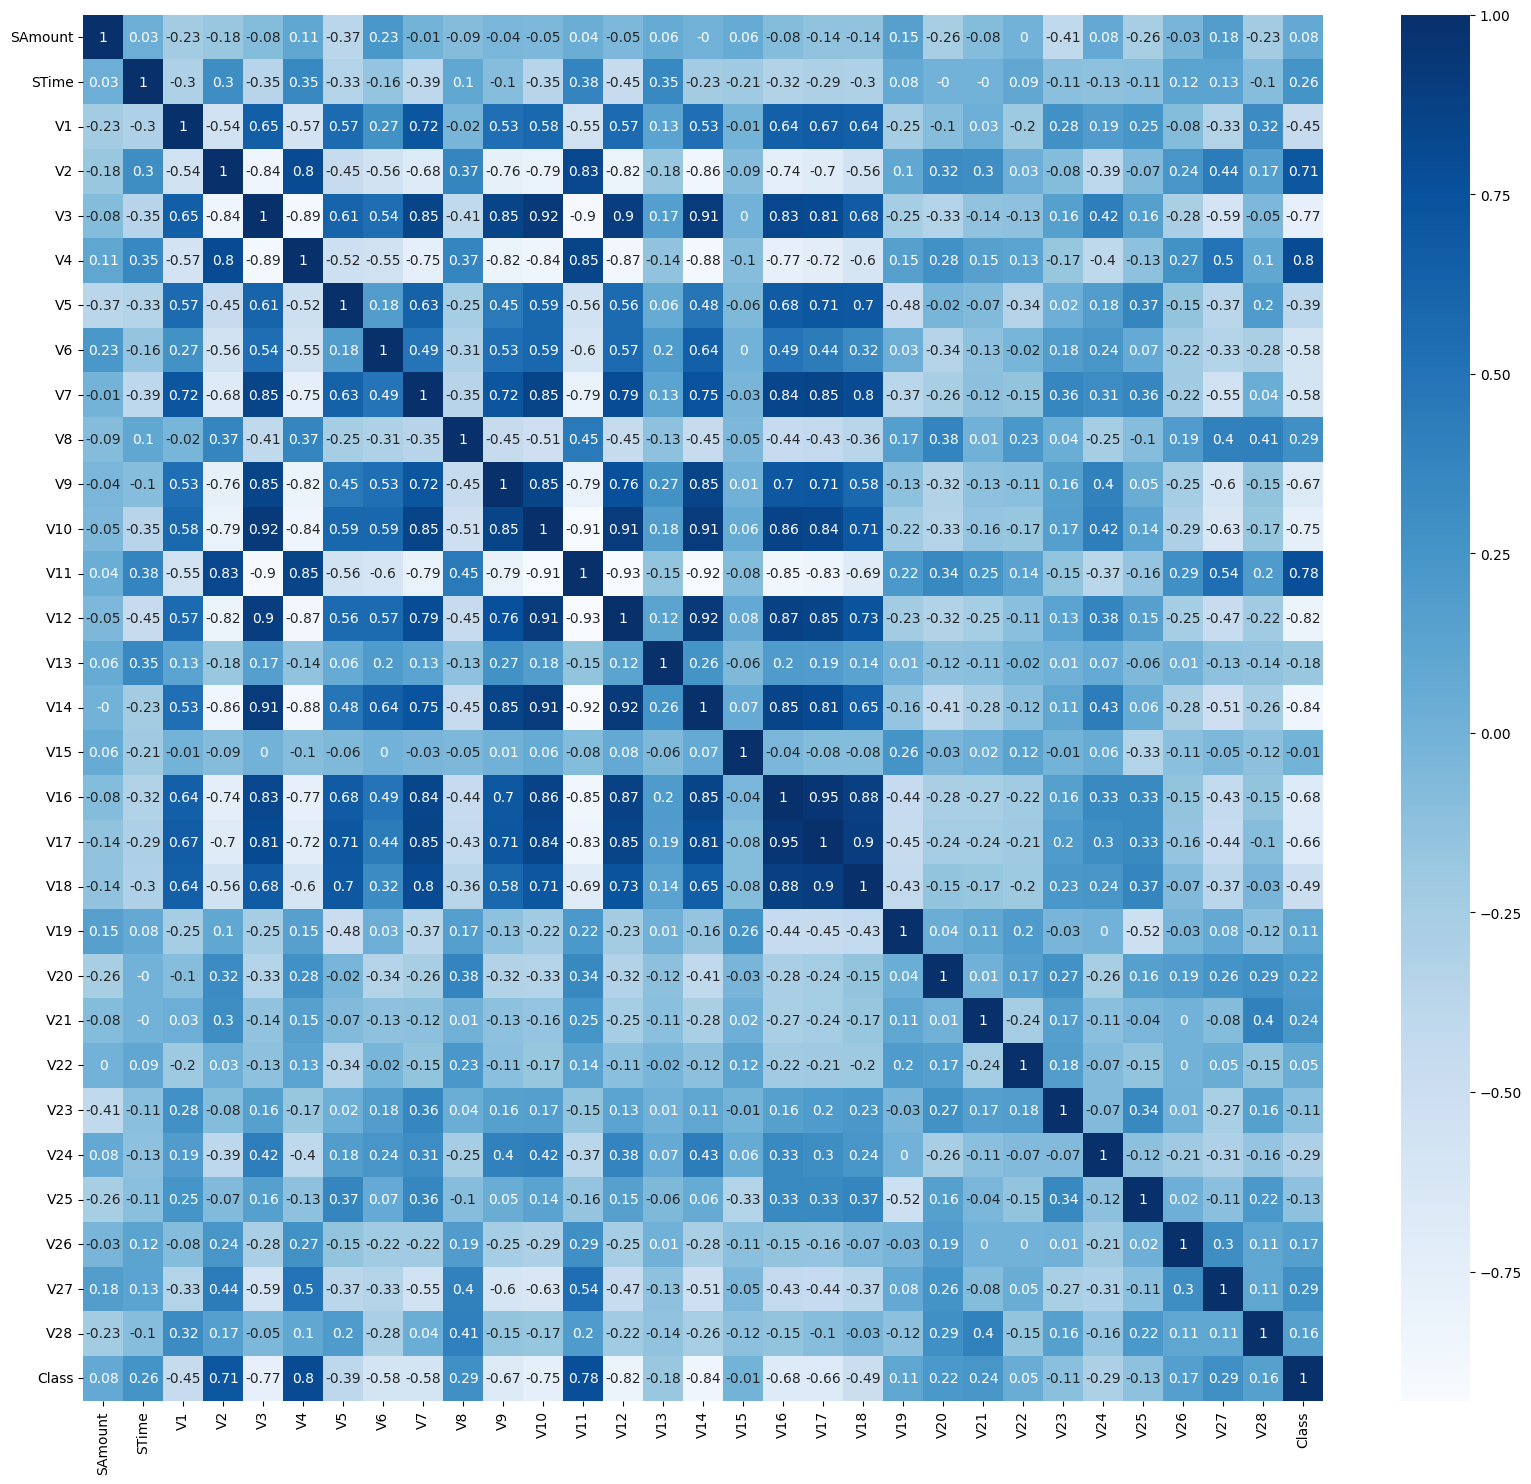

In [282]:
plt.figure(figsize=(20,18))
sns.heatmap(df_cc_os.corr().round(2), annot=True, cmap='Blues')
plt.show()

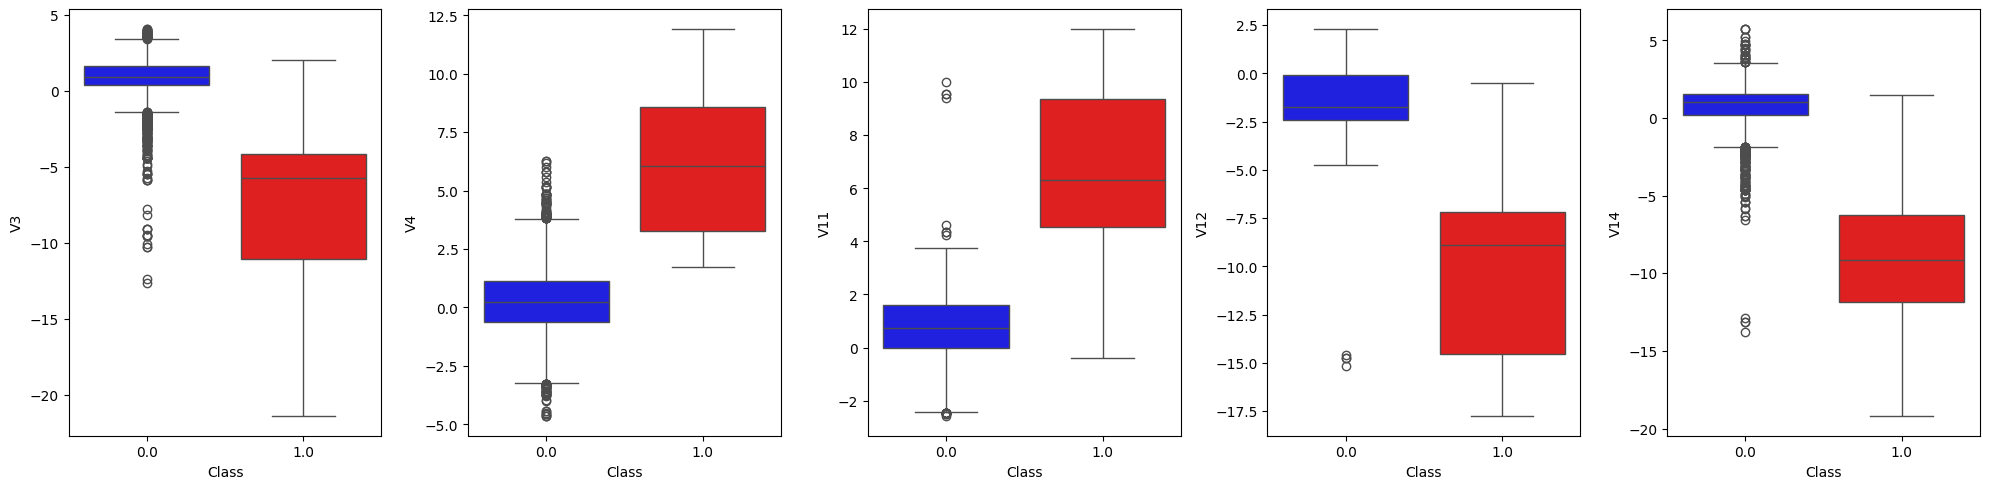

In [283]:
#v12, v4, v11, v12, v14
fig, axes = plt.subplots(1, 5, figsize=(20,5))

sns.boxplot(x='Class', y='V3', data=df_cc_os, palette=['b', 'r'], ax=axes[0])

sns.boxplot(x='Class', y='V4', data=df_cc_os, palette=['b', 'r'], ax=axes[1])

sns.boxplot(x='Class', y='V11', data=df_cc_os, palette=['b', 'r'], ax=axes[2])

sns.boxplot(x='Class', y='V12', data=df_cc_os, palette=['b', 'r'], ax=axes[3])

sns.boxplot(x='Class', y='V14', data=df_cc_os, palette=['b', 'r'], ax=axes[4])

plt.tight_layout()
plt.show()

In [284]:
#distribution plot
from scipy.stats import norm

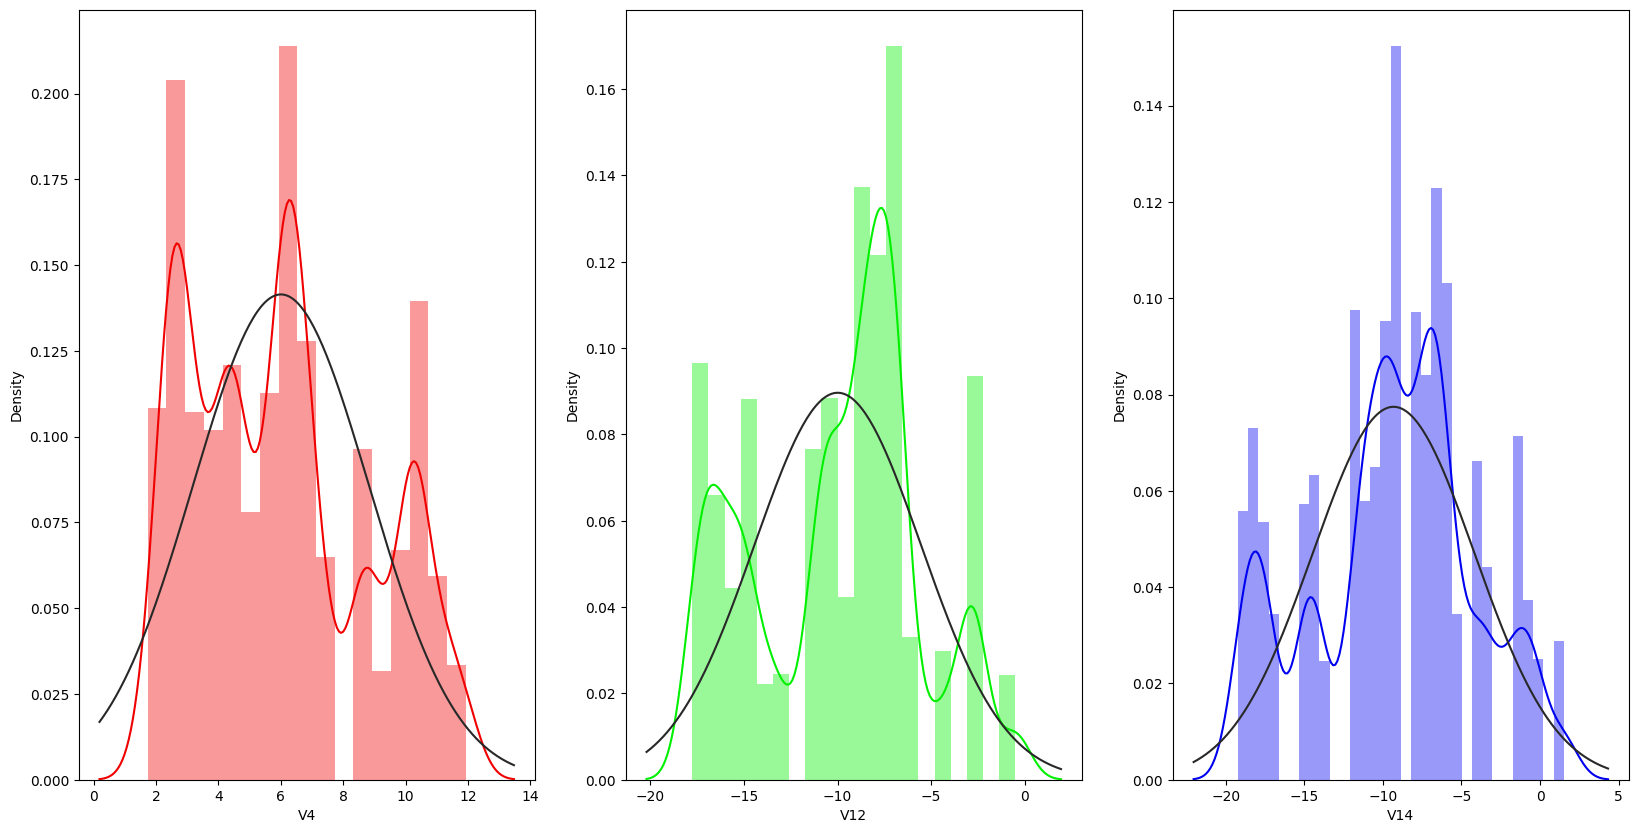

In [285]:
fig, axes = plt.subplots(1, 3, figsize=(20,10))

sns.distplot(df_cc_os.loc[df_cc_os['Class']==1, 'V4'],
            fit=norm, color='#F00000', ax=axes[0])
sns.distplot(df_cc_os.loc[df_cc_os['Class']==1, 'V12'],
            fit=norm, color='#00F000', ax=axes[1])
sns.distplot(df_cc_os.loc[df_cc_os['Class']==1, 'V14'],
            fit=norm, color='#0000F0', ax=axes[2])
plt.show()

In [286]:
# # #remove outlier
# cols = ['V3', 'V4', 'V11', 'V12', 'V14']

# for c in cols:
#   q1 = df_cc_os[c].quantile(0.25)
#   q3 = df_cc_os[c].quantile(0.75)
#   iqr = q3 - q1
#   lower_limit = q1 - (3 * iqr)
#   upper_limit = q3 + (3  * iqr)
#   df_cc_os = df_cc_os[(df_cc_os[c] >= lower_limit) &
#                       (df_cc_os[c] <= upper_limit)]


<Axes: xlabel='Class', ylabel='count'>

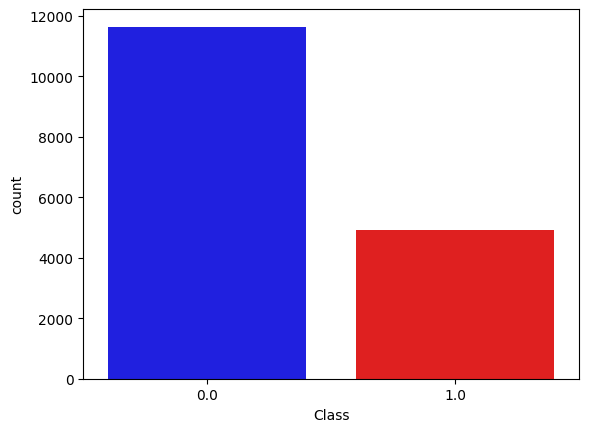

In [287]:
sns.countplot(x='Class', data=df_cc_os, palette=['b', 'r'])

In [288]:
# Decomposition (Dimensionality Reduction) and Clustering
# 1. t-SNE decomposition (or clustering) method;
#    t=t-distribution, SNE-Stochastic(random) Neighbor Embedding
# 2. PCA
# 3. TruncatedSVD

X = df_cc_os.drop(columns='Class')
y = df_cc_os['Class']

model_tsne = TSNE(n_components=2, random_state=42)
X_reduced_tsne = model_tsne.fit_transform(X.values)

model_pca = PCA(n_components=2, random_state=42)
X_reduced_pca = model_pca.fit_transform(X.values)

model_tsvd = TruncatedSVD(n_components=2, random_state=42)
X_reduced_tsvd = model_tsvd.fit_transform(X.values)



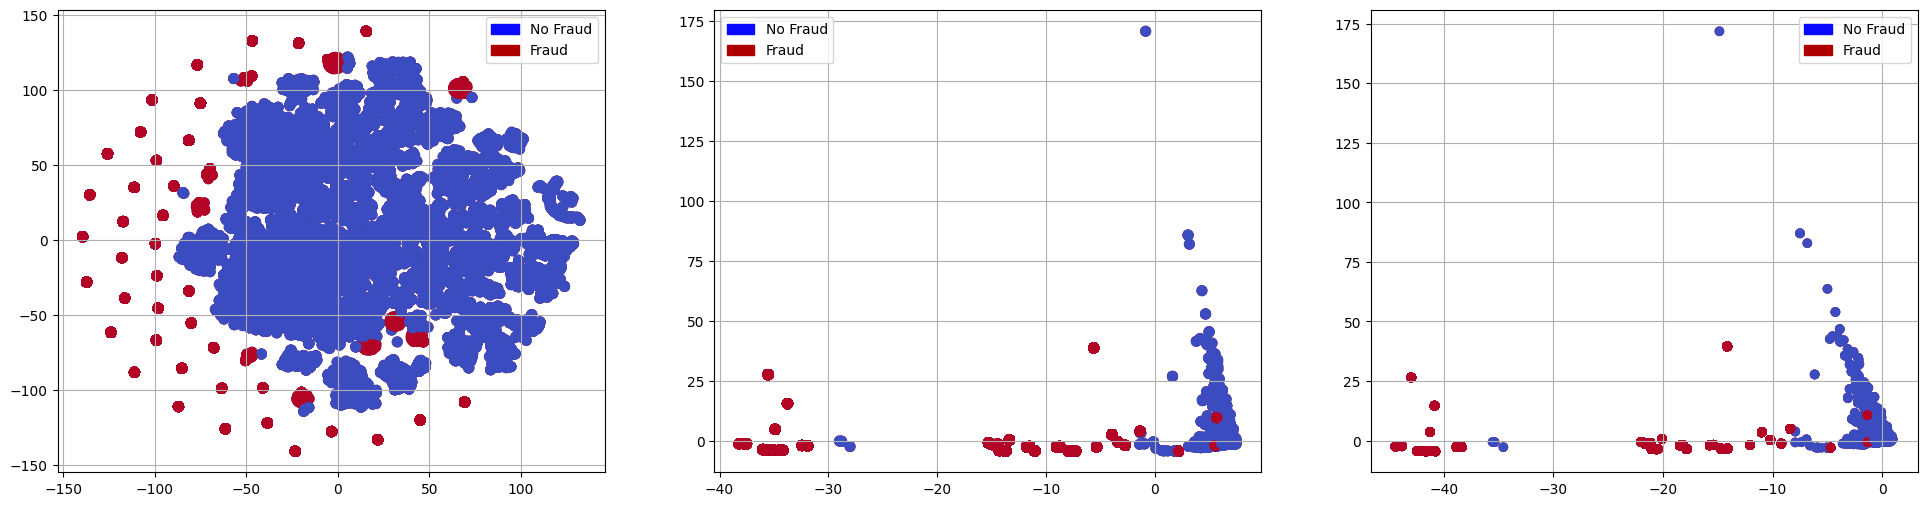

In [289]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(24,6))

blue_patch = mpatches.Patch(color='#0A0AFF', label='No Fraud')
red_patch = mpatches.Patch(color='#AF0000', label='Fraud')

ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1],
                c=(y==0), cmap='coolwarm', label='Not Fraud', linewidths=2)
ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1],
                c=(y==1),cmap='coolwarm', label='Fraud', linewidths=2)
ax1.grid(True)
ax1.legend(handles=[blue_patch, red_patch])


ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1],
                c=(y==0), cmap='coolwarm', label='Not Fraud', linewidths=2)
ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1],
                c=(y==1), cmap='coolwarm', label='Fraud', linewidths=2)
ax2.grid(True)
ax2.legend(handles=[blue_patch, red_patch])

ax3.scatter(X_reduced_tsvd[:,0], X_reduced_tsvd[:,1],
                c=(y==0), cmap='coolwarm', label='Not Fraud')
ax3.scatter(X_reduced_tsvd[:,0], X_reduced_tsvd[:,1],
                c=(y==1), cmap='coolwarm', label='Fraud')
ax3.grid(True)
ax3.legend(handles=[blue_patch, red_patch])

In [290]:
model_pca.components_

array([[-0.03496435, -0.0172028 ,  0.1514524 , -0.15940753,  0.36827763,
        -0.23163681,  0.10646563,  0.07547778,  0.2650281 , -0.05566763,
         0.15302396,  0.29000261, -0.24498456,  0.36110363,  0.01634582,
         0.41264293,  0.00186931,  0.23309411,  0.35835816,  0.12314048,
        -0.02562433, -0.01803177, -0.0181325 , -0.00801555,  0.02502741,
         0.0193254 ,  0.01356792, -0.01059156, -0.03736264, -0.00429855],
       [ 0.9431746 ,  0.00275431, -0.12584447, -0.1149906 ,  0.0063562 ,
         0.00207837, -0.14102651,  0.09409362,  0.01249802, -0.04204631,
         0.02262259,  0.02806162, -0.03587439,  0.0405266 ,  0.01746627,
         0.1130308 ,  0.01573937, -0.01956752, -0.0934349 , -0.04959722,
         0.03777874, -0.04061022, -0.02317717,  0.00240554, -0.1218787 ,
         0.01506531, -0.04428011, -0.00710304,  0.01739033, -0.02233642]])

In [291]:
#use different classifiers to predict fraud or not fraud transaction
#split train test dataset

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.25,
                                                    random_state=42)


In [292]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


In [293]:
classifiers = {'LogisticRegression': LogisticRegression(),
               'KNearestNeighbors': KNeighborsClassifier(),
               'DecisionTreeClassifier': DecisionTreeClassifier(),
               'SupportVectorMachine': SVC()}


In [294]:
from sklearn.model_selection import cross_val_score, cross_validate

In [295]:
from sklearn.metrics import accuracy_score

In [296]:
for cname, model_cfr in classifiers.items():
  model_cfr.fit(x_train, y_train)
  print('Classifier: ', cname, ',  Acc.Score: ',
        accuracy_score(y_test, model_cfr.predict(x_test)))

Classifier:  LogisticRegression ,  Acc.Score:  0.9951702487321903
Classifier:  KNearestNeighbors ,  Acc.Score:  0.9983095870562666
Classifier:  DecisionTreeClassifier ,  Acc.Score:  0.9992755373098285
Classifier:  SupportVectorMachine ,  Acc.Score:  0.9966191741125332


In [297]:
for cname, model_cfr in classifiers.items():
  cv_score = cross_val_score(model_cfr, x_train, y_train, cv=5)
  print('Classifier: ', cname, ',  Acc.Score: ', cv_score.mean().round(6))

Classifier:  LogisticRegression ,  Acc.Score:  0.9967
Classifier:  KNearestNeighbors ,  Acc.Score:  0.998954
Classifier:  DecisionTreeClassifier ,  Acc.Score:  0.999356
Classifier:  SupportVectorMachine ,  Acc.Score:  0.993882


In [298]:
from sklearn.model_selection import GridSearchCV

In [299]:
lr_params = {'penalty': ['l1', 'l2'],
             'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}
log_reg_gs_cv = GridSearchCV(estimator=LogisticRegression(),
                             param_grid=lr_params,
                             cv=5)
log_reg_gs_cv.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
                         'penalty': ['l1', 'l2']})

In [300]:
log_reg_gs_cv.best_params_

{'C': 1000, 'penalty': 'l2'}

In [301]:
knears_params = {'n_neighbors': list(range(2, 5, 1)),
                 'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']}
knears_gs_cv = GridSearchCV(estimator=KNeighborsClassifier(),
                            param_grid=knears_params,
                            cv=5)
knears_gs_cv.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
                         'n_neighbors': [2, 3, 4]})

In [302]:
knears_gs_cv.best_params_

{'algorithm': 'auto', 'n_neighbors': 2}

In [303]:
svc_params = {'C': [0.5, 0.7, 0.9, 1],
              'kernel': ['linear', 'poly', 'sigmoid', 'rbf'] }
svc_gs_cv = GridSearchCV(SVC(), svc_params)
svc_gs_cv.fit(x_train, y_train)
svc_gs_cv.best_params_


{'C': 0.7, 'kernel': 'linear'}

In [304]:
tree_params = {'max_depth': [2, 3],
               'criterion': ['gini', 'entropy'],
               'min_samples_leaf': [5, 6],
               }
tree_gs_cv = GridSearchCV(DecisionTreeClassifier(), param_grid=tree_params)
tree_gs_cv.fit(x_train, y_train)
tree_gs_cv.best_params_

{'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 6}

In [305]:
model_cvs = [log_reg_gs_cv, knears_gs_cv, svc_gs_cv, tree_gs_cv]

for mcv in model_cvs:
  score = cross_val_score(estimator=mcv, X=x_train, y=y_train, cv=5)
  print('Model: ',mcv.best_estimator_, '  Params: ', mcv.best_params_ ,
        ' Score:', score.mean().round(5))


Model:  LogisticRegression(C=1000)   Params:  {'C': 1000, 'penalty': 'l2'}  Score: 0.99662
Model:  KNeighborsClassifier(n_neighbors=2)   Params:  {'algorithm': 'auto', 'n_neighbors': 2}  Score: 0.99968
Model:  SVC(C=0.7, kernel='linear')   Params:  {'C': 0.7, 'kernel': 'linear'}  Score: 0.99718
Model:  DecisionTreeClassifier(max_depth=3, min_samples_leaf=6)   Params:  {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 6}  Score: 0.98801


In [306]:
from sklearn.model_selection import (train_test_split,
                                     StratifiedKFold,
                                     StratifiedGroupKFold,
                                     ShuffleSplit,
                                     StratifiedShuffleSplit)
from sklearn.model_selection import learning_curve

In [307]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_predict

In [308]:
models_best = [log_reg_gs_cv.best_estimator_,
               knears_gs_cv.best_estimator_,
               tree_gs_cv.best_estimator_,
               svc_gs_cv.best_estimator_]
y_pred = list()
for model in models_best:
  y_pred.append(cross_val_predict(estimator=model, X=x_train, y=y_train, cv=5))
  # print(y_pred[-1])
  print(model.__class__.__name__, ': ',
        roc_auc_score(y_train, y_pred[-1]).round(5))


LogisticRegression :  0.9977
KNeighborsClassifier :  0.99977
DecisionTreeClassifier :  0.98449
SVC :  0.99805


In [309]:
# np.sum([False  if len(y_pred[p]) == len(y_pred[p-1]) else True for p in range(1, len(y_pred))])
np.diff([p.shape for p in y_pred]).sum()

np.int64(0)

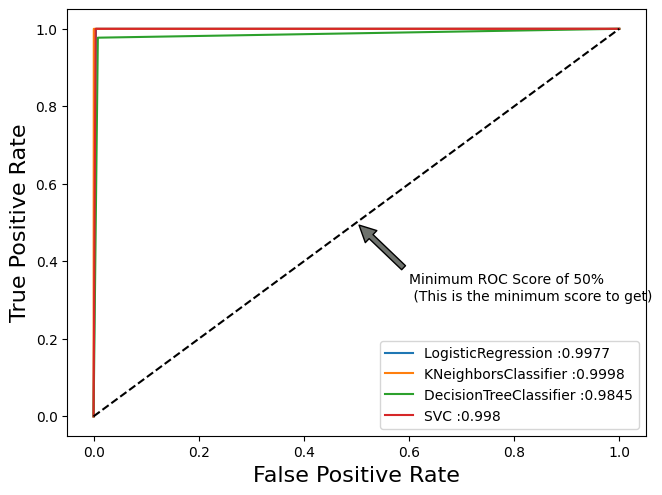

In [310]:
for i in range(len(y_pred)):
  fpr, tpr, threshold = roc_curve(y_true=y_train, y_score=y_pred[i])
  plt.plot(fpr, tpr,
           label=models_best[i].__class__.__name__+' :'
           + str(roc_auc_score(y_train, y_pred[i]).round(4)))

plt.legend()
plt.plot([0,1],[0,1], 'k--')
# plt.axis([-0.01, 1, 0, 1])
plt.tight_layout()
plt.xlabel('False Positive Rate', fontsize=16)
plt.ylabel('True Positive Rate', fontsize=16)
plt.annotate('Minimum ROC Score of 50% \n (This is the minimum score to get)', xy=(0.5, 0.5), xytext=(0.6, 0.3),
                arrowprops=dict(facecolor='#6E726D', shrink=0.05),
                )
plt.show()

In [311]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.model_selection import StratifiedKFold


In [328]:
from sklearn.metrics import (accuracy_score,
                             precision_score,
                             recall_score,
                            #  support_score,
                             f1_score,
                             roc_auc_score)

In [312]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [313]:
for i, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
  print(train_idx.shape, test_idx.shape)
# i.e cv=skf_object in any XXSearchCV

(13251,) (3313,)
(13251,) (3313,)
(13251,) (3313,)
(13251,) (3313,)
(13252,) (3312,)


In [314]:
model_lr = LogisticRegression()
param_dist = {
    'penalty':['l1', 'l2', 'l3'],
    'C': np.logspace(-3, 3, 7)
}
rs_cv = RandomizedSearchCV(estimator=model_lr,
                          n_iter=10,
                          n_jobs=-1,
                          param_distributions=param_dist,
                           scoring='f1',
                          cv=skf)
rs_cv.fit(x_train, y_train)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=LogisticRegression(), n_jobs=-1,
                   param_distributions={'C': array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03]),
                                        'penalty': ['l1', 'l2', 'l3']},
                   scoring='f1')

In [315]:
rs_cv.best_params_

{'penalty': 'l2', 'C': np.float64(1000.0)}

In [316]:
rs_cv.best_estimator_

LogisticRegression(C=np.float64(1000.0))

In [317]:
param_dist={
    'penalty': ['l1', 'l2', 'l3'],
    'C': np.logspace(-3, 3, 7),
    }
rs_cv2 = RandomizedSearchCV(
    estimator=LogisticRegression(),
    param_distributions=param_dist,
)

In [337]:
lst_roc_auc, lst_accuracy, lst_precision, lst_recall = [], [], [], []
lst_support, lst_f1 = [], []

In [339]:
for train_idx, test_idx in skf.split(x_train, y_train):
  pipeline = imbal_make_pipeline(SMOTE(sampling_strategy='minority'),
                                rs_cv2)
  pipeline.fit(x_train.iloc[train_idx], y_train.iloc[train_idx])
  y_pred = rs_cv2.best_estimator_.predict(x_train.iloc[test_idx])
  lst_accuracy.append(accuracy_score(y_train.iloc[test_idx], y_pred))
  lst_precision.append(precision_score(y_train.iloc[test_idx], y_pred))
  lst_recall.append(recall_score(y_train.iloc[test_idx], y_pred))
  # lst_support.append(support_score(y_train.iloc[test_idx], y_pred))
  lst_f1.append(f1_score(y_train.iloc[test_idx], y_pred))

print(f'Accuracy: {np.mean(lst_accuracy):2f}')
print(f'Precision: {np.mean(lst_precision):2f}')
print(f'Recall: {np.mean(lst_recall):2f}')
print(f'f1 score: {np.mean(lst_f1):2f}')



Accuracy: 0.995331
Precision: 0.984682
Recall: 1.000000
f1 score: 0.992272
